## **Basic Neural Network Workflow (with PyTorch)**

![Neural Network Workflow](images/neural_network_workflow.png "Neural Network Workflow")

Things covered in the following tutorial

| Topic | Contents |
|----------|----------|
| **1. Getting data ready** | For this tutorial, we'll be modeling a simple **straight line** using a **neural network** (a type of machine learning **model**) |
| **2. Building a model** | We'll create a neural network, alongisde choosing a **loss function** and **optimizer** and creating a **training loop** |
| **3. Fitting the model to data (training)** | We'll run the neural network through the training loop to let it learn **patterns** in the **train** data |
| **4. Making predictions and evaluating a model (inference and testing)** | The neural network we made learned some patterns, so now we have to verify them using the **test** data |
| **5. Saving and loading a model** | We might want to use the model later, so let's save it |

Let's create a dictionary for all the steps we're covering in this tutorial

In [22]:
steps_of_tutorial = {1: "getting data ready (prepare and load)",
    2: "building model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating a model (inference and testing)",
    5: "saving and loading a model"
}

Now, let's import the libraries necessary to create our first neural network!

In [1]:
import torch    # The full package for PyTorch, a common library for making very customizable neural networks
from torch import nn   # "nn" stands for neural network - this section of PyTorch contains the building blocks for neural networks
import matplotlib.pyplot as plt     # A library to help create graphs

# Check PyTorch version - "x.x.x" indicates the version of PyTorch, while "+cuXXX" shows the version of cuda 
# (a backend that helps run neural networks even faster on GPUs!) it is compatible with
torch.__version__

'2.3.1+cu121'

### **1. Getting data ready (preparing and loading)**

Machine learning needs you to:
1. Turn your data into numbers (a "numerical representation")
2. Pick or build a model to learn patterns about the representation as best as possible

Right now, we don't have any data. Instead we'll make some data - a straight line.

We'll create the data with known **parameters** (values that are learned by a model) and see if we can build a neural network from PyTorch to **estimate these same values** by finding patterns within the training data

In [2]:
# Create our "known" parameters
weight = 0.7
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)     # our "features"
y = weight * X + bias   # our "labels"

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

Now, we're going to build a model that can learn the relationship between `X` (**features**) and `y` (**labels**)

#### Split data into train and test sets

We have some data for a straight line, but we need to split it up into a training and testing set (and sometimes a validation set).

| Split | Purpose | Proportion of total data | How often is it used? |
|----------|----------|----------|----------|
| **Train set** | The model learns from this data (like the notes you study from) | ~60-80% | Always |
| **Validation set** | The model shows its performance on this data while learning (like a practice test before the actual test) | ~10-20% | Often, but not always |
| **Testing set** | The model gets evaluated on this data to see what it's learned (like the actual test) | ~10-20% | Always |

We're only going to use a training and testing set for this example. We can create them by splitting the `X` and `y` values.

> Note: When using real-world data, this is one of the first steps to keep the test set separate from the other data. We want the model to learn from train data and see how it good it does on test data to learn how well it **generalizes** to examples its never seen before.

In [3]:
# Create train/test split
train_split = int(0.8 * len(X)) # 80% of data used for training set, 20% for testing 

# Often, this process can be done with a another Python library
# However, to keep things simple, we'll do it manually
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Now we have 40 samples for training (`X_train` and `y_train`) alongside 10 samples for testing (`X_test` and `y_test`). The neural network we create will try to learn the relationship between `X_train` and `y_train`, and then we'll see what relationships were found by using `X_test` and `y_test`

Let's see how these values actually look with a graph

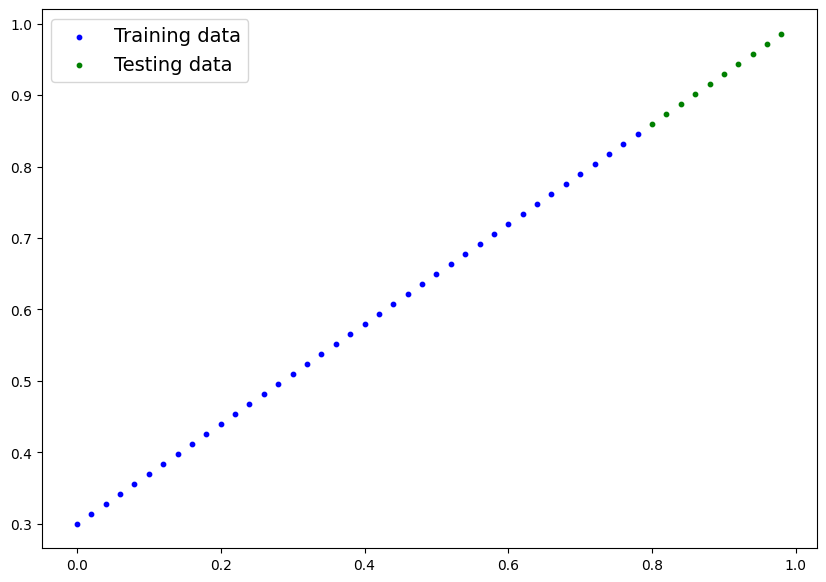

In [4]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=10, label="Training data")
    
    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=10, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=10, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})

# Note: visualizing is always a great way to look at and understand data
# It's also great for learning any concept in general
plot_predictions()

### **2. Build model**

We've made our straight line data. Now, let's make a neural network to learn patterns from the blue dots to predict the green dots.

PyTorch has (loosely) four modules that are needed to create any kind of neural network.

They are `torch.nn`, `torch.optim`, `torch.utils.data.Dataset` and `torch.utils.data.DataLoader`. For this tutorial, we will only talk about the first two.

| PyTorch module | What does it do? |
|----------|----------|
| `torch.nn` | Has all the building blocks for neural networks |
| `torch.nn.Parameter` | Stores values to be used in `nn.Module`. If `requires_grad=True`, then calculations for learning about training data are done automatically - this is often named "autograd". |
| `torch.nn.Module` | The base class for all neural networks. If you're building a neural network in PyTorch, your model should be built on top of (subclass) `nn.Module`, and the `forward()` method should be overwritten |
| `torch.optim` | Contains various methods to help the neural network learn. It takes the values in `nn.Parameter` and tells it how to best change to minimize the error between real values and values predicted by the neural network |
| `def forward` | All `nn.Module` subclasses require a `forward()` method. This defines the computation that will take place on the data passed to the `nn.Module` |

Everything in a PyTorch neural network comes from `torch.nn`.
- `nn.Module` has the larger building blocks (layers)
- `nn.Parameter` has the smaller building blocks (that can be put together to make a `nn.Module`)
- `forward()` tells the larger and smaller building blocks how to change the input data to more closely resemble the output
- `torch.optim` contains different ways for the neural network to improve the `nn.Parameter`s to better change the input data to resemble the output data

In [5]:
# Creating a neural network to learn how to continue a straight line with the same parameters (weight/bias) we made it from
class LinearRegressionModel(nn.Module): # We just took all the information from "nn.Module" and put it in the class we're building
    # Almost everything in PyTorch is a nn.Module (the neural network "lego blocks")
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(
            torch.randn(1,  # This starts with a random weight, but it gets adjusted as the model learns
                        dtype=torch.float), # Generic data type for PyTorch
            requires_grad=True  # Can we update this value as the model is learning? If this is "true", then we can update it
        )

        self.bias = nn.Parameter(
            torch.randn(1,  # This starts with a random weight, but it gets adjusted as the model learns
                        dtype=torch.float), # Generic data type for PyTorch
            requires_grad=True  # Can we update this value as the model is learning? If this is "true", then we can update it
        )

        # All of the contents can be replaced by a simple nn.Module named "nn.Linear"
        # Instead of defining two parameters one-by-one, you could use the following line to make the code more concise
        # This is always done when regularly coding neural networks
        # self.linear_layer = nn.Linear(in_features = 1, out_features = 1)

    # Forward 
    def forward(self, x):   # "x" is the input data 
        return self.weight * x + self.bias  # This is the same formula for a line (y = m * x + b)
        # This converts our input data into an output and compares that with data from the "true" line we made

        # If we use our `self.linear_layer`, we can just do the following:
        # return self.linear_layer(x)

#### Checking the contents of a PyTorch neural network model

Now that we've defined our model with a class, let's make a model and check its parameters using `.parameters()`

In [6]:
# Set manual seed for reproducible randomness since nn.Parameter(s) are randomly initialized
# ^ "s" is in parentheses next to nn.Parameter above since the function's true name does not have an "s"
torch.manual_seed(42)

# Create an instance of the simple model we made
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module version we made
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

We can also get the state (the contents) of the model using `.state_dict()`

In [7]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

The values of `weight` and `bias` are random because we initialized them with a random function (`torch.randn()`)

We want to start from random parameters (weights/biases), and get the neural network to update them towards parameters that fit the data the best.

In this case, the best possible values for `weight` and `bias` are the hard-coded values we set earlier, 0.7 and 0.3, respectively.

Because our model starts with a random `weight` and `bias`, the current predictions are going to be completely off-target

#### Making predictions using `torch.inference_mode()`

To check how bad the current parameters are, we can pass it the test data, `X_test`, and compare it to the `y_test` values.

When we pass data to our model, it'll go through the model's `forward()` that we defined earlier and produced a result based on that computation

When doing model evaluation, we want to use `torch.inference_mode()` to turn off a bunch of things that are needed for training but unnecessary for testing. This makes evaluation faster altogether.

In [8]:
# Make predictions with the model
with torch.inference_mode():
    y_preds = model_0(X_test)

# Note: in older PyTorch code, you might also see torch.no_grad() for inference
# torch.inference_mode() and torch.no_grad() do similar things, but torch.inference_mode() is newer, possibly faster, and now preferred
# with torch.no_grad():
#     y_preds = model_0(X_test)

Now, let's see what the predictions look like

In [9]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


There's only one prediction value per testing sample, since our data takes one `X` value and maps it to one `y` value. However, machine learning models are flexible, and can take any amount of `X` values and map to any amount of `y` values.

Let's visualize our predictions to see how bad they are

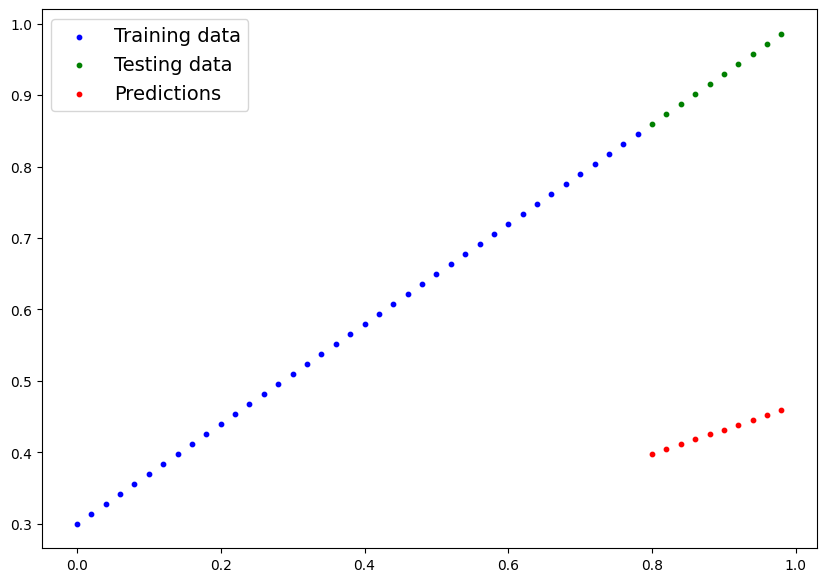

In [10]:
plot_predictions(predictions=y_preds)

In [11]:
y_test - y_preds    # Subtracting y_preds from y_test to see how far away they are

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

Like we thought, these predictions are pretty bad, since we're just using random parameter values to make predictions rather than training the neural network and then making predictions

### **3. Train model**

Right now, the model is basically guessing. We just used random parameters to make predictions on our test data rather than learning anything new beforehand.

To fix that, we can update the parameters (also colloquially referenced as their patterns), or the `weight` and `bias` values we set randomly with `nn.Parameter()` and `torch.randn()`, to be something that better represents the data

We could manually change the `weight` and `bias` values within our model to be 0.7 and 0.3. But, if we had hundreds of thousands of parameters, where we don't even know the ideal values, this would be impossible.
> Note: ChatGPT 3 (which is an older version - the current version is ChatGPT 5) has 175 billion parameters. Imagine changing all of those by hand!

#### Creating a loss function and optimizer in PyTorch

For our model to update its parameters and actually start learning, we need a few more things: a loss function, and an optimizer.

| Function | What does it do? | Where does it live in PyTorch? | Common values |
|----------|----------|----------|----------|
| **Loss function** | Measures how wrong your model's predictions (`y_pred`) are compared to the truth labels (`y_test`). Usually, the lower the better | PyTorch has many built-in loss functions in `torch.nn` | Mean absolute error (MAE) or mean squared error (MSE) for regression problems (`torch.nn.L1Loss()`, `torch.nn.MSELoss()`), and binary cross entropy for binary classification problems (`torch.nn.BCELoss()`)|
| **Optimizer** | Tells your model how exactly to update its internal parameters to best lower the loss | PyTorch has many built in optimization algorithms implemented in `torch.optim` | Stochastic gradient descent (`torch.optim.SGD()`), or the Adam optimizer (`torch.optim.Adam()`) |

Depending on the problem at hand, the loss function and optimizer will change, but there are common choices for certain problems that are known to work well.

Since we're predicting a number in this example, we'll use the mean absolute error (calculated with `torch.nn.L1Loss`). This takes the difference between the predicted values and the actual values from the true line for all supplied predicted values, and then takes the mean across all differences calculated. Here, a lower loss value is more ideal, since that means the predicted values are getting closer to the real values.

![MAE Visualization](images/MAE_visualization.png "MAE Visualization")

For the optimizer, we'll use SGD, which is the most basic algorithm. The syntax for this is `torch.optim.SGD(params, lr)`:
- `params` are the weights/biases that are tuned over time to learn the characteristics of our line
- `lr` is the learning rate, or a hyperparameter (a value set by someone creating the model) that controls how big of a step the model takes based off of information from the loss value. The larger the learning rate, the larger the steps taken by the optimizer when changing the parameters.
  - Larger values can make training unstable, as the parameters can jump around the ideal values rather than settling and converging at them
  - Smaller values can cause the model to take a long time to reach more ideal parameter values 

In [12]:
# Create the loss function
loss_fn = nn.L1Loss()   # L1Loss is the same as MAE

# Create the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),     # The weights/biases from the model that is learning
                            lr=0.01)    # Learning rate - determines the relative size of the adjustments when training

#### Creating a training loop in PyTorch

Now, with a loss function and an optimizer, to actually make the model learn, we'll create a training loop and a testing loop. 
- Training loop: Here, the model uses its weights and biases, and takes training data (`features`) to predict values similar to the actual data, or the `labels`. Then, that output will be compared to the true results using the loss function, and then information will be sent to the optimizer to tell it how to update the parameters based on how bad the predictions were
- Testing loop: Now, whatever the model is learning from the training loop is put to the test by giving it data its never seen before (test data). Good performance on the test data indicates the model is learning patterns to take `features` and convert them into `labels` in a manner that is generalizable to new cases that it hasn't even learned from

Each of these are a loop because the model can't learn all the necessary information in one go. It has to try and fail, again and again.

#### PyTorch training loop

The following steps are always in every PyTorch training loop.

| Number | Step name | What does it do? | Code example |
|----------|----------|----------|----------|
| 1 | Forward pass | The model performs the calculations in its `forward()` method on all of the training data passed as an argument. | `model_0(X_train)` |
| 2 | Calculate the loss | The model's predictions from the previous `forward()` calculations are compared to the true values from the line, and they are evaluated based on how wrong they are. | `loss = loss_fn(y_pred, y_train)` |
| 3 | Zero gradients | The optimizer's previous updates are cleared out so they can be recalculated again for the current training step. | `optimizer.zero_grad()` |
| 4 | Perform backpropagation using the loss | Calculates the portion of the model parameter updates (for all parameters with `requires_grad=True`) that is based on how bad the loss is. This calculation is known as backpropagation. | `loss.backward()` |
| 5 | Update the optimizer | Update all parameters with `requires_grad=True` based on information from the loss alongside the learning rate size in order to improve the model | `optimizer.step()` |


> Note: These are just the essential steps. However, training loops are highly flexible in order and content. When trying to create your own training loops, just remember these rules:
> - Calculate the loss (`loss = loss_fn(y_pred, y_train)`) before doing `loss.backward()`
> - Reset the optimizer's previous updates (`optimizer.zero_grad()`) before computing the next updates using `loss.backward()`
> - Update the model parameters with `optimizer.step()` after getting necessary information for the updates from `loss.backward()`

> Second note: Before starting to train a model, make sure that the model is in training mode using `model_0.train()`. 

#### PyTorch testing loop

For the testing loop, we have a few typical steps:

| Number | Step name | What does it do? | Code example |
|----------|----------|----------|----------|
| 1 | Forward pass | The model performs the calculations in its `forward()` method on all of the testing data passed as an argument. | `model_0(X_train)` |
| 2 | Calculate the loss | The model's predictions from the previous `forward()` calculations are compared to the true values from the line, and they are evaluated based on how wrong they are. | `loss = loss_fn(y_pred, y_train)` |
| 3 | Calculate evaluation metrics  | To judge model performance even further, other evaluation metrics might be calculated, such as accuracy or root mean squared error. | Custom code |

> Note: Before starting to evaluate a model, make sure the model is in evaluation mode using `model_0.eval()`

Here, there is no `loss.backward()` or `optimizer.step()` since the model doesn't learn from the testing set. We just want to see how the model is performing on data it has never seen before.

Let's create a training loop that runs for 100 epochs (the total amount of iterations through the whole dataset - the amount of tries the model gets to learn), and a testing scheme that evaluates the model every 10 epochs.

In [13]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training ###

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer to clear out previous update information
    optimizer.zero_grad()

    # 4. Loss backwards to inform the optimizer for model updates
    loss.backward()

    # 5. Progress the optimizer and update model parameters
    optimizer.step()

    ### Testing ###

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
        # 1. Forward pass on test data
        test_pred = model_0(X_test)

        # 2. Caculate loss on test data
        test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening
        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495 
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428 
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688 
Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703 
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106 
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024 
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135 
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519 
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484 
Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819 


The training and testing loss is going down after each set of epochs. Our model is actually learning! Let's visualize the training and testing loss by plotting them.

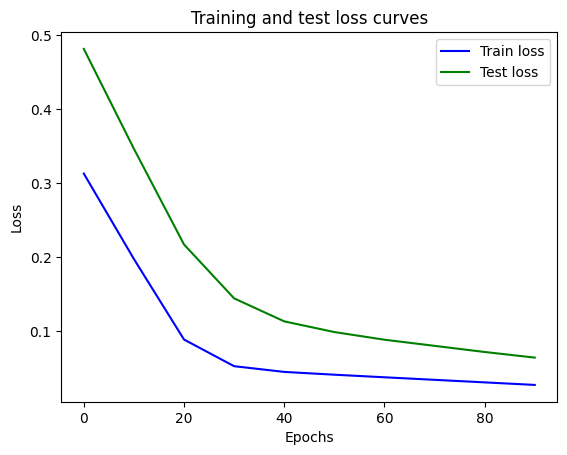

In [14]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss", c="b")
plt.plot(epoch_count, test_loss_values, label="Test loss", c="g")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

Since the loss values are decreasing over each epoch, that means the predicted values are getting closer and closer to the real values!

To see why the loss value was actually going down, we can compare the weight and bias of our model to the true weight and bias we set at the beginning of the tutorial. If the model's weight and bias are close to the actual weight and bias, the model is now using the formula with more correct parameters, which gives more accurate predictions 

In [15]:
# Find our model's learned parameters
print("The model learned the following values for the weight and bias:")
print(model_0.state_dict())
print("\nAnd the original values for the weight and bias are:")
print(f"Weight: {weight}, Bias: {bias}")

The model learned the following values for the weight and bias:
OrderedDict({'weight': tensor([0.5784]), 'bias': tensor([0.3513])})

And the original values for the weight and bias are:
Weight: 0.7, Bias: 0.3


This same learning process can be done for data and tasks from several different industries!

By seeing this, you should understand the potential of machine learning. There are always ideal values that describe the patterns of data. Rather than figuring out these ideal values by hand, we can create a machine learning model to figure them out computationally and iteratively.

### **4. Making predictions and evaluating a model (inference and testing)**

After training a model, we want to make predictions with it to see how well the model ended up learning in the end. It's similar to the code found in the training/testing loop.

When making predictions, or performing inference, with a PyTorch model, there are two basic ideas:
- Set the model in evaluation mode `model_0.eval()`
- Make predictions using the inference mode context manager (`with torch.inference_mode():`)

This makes sure that all the calculations that PyTorch does behind the scenes for training but aren't necessary for inference are turned off, leading to faster predictions.

In [16]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  y_preds = model_0(X_test)
y_preds

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

Let's see how the predictions from our trained model look

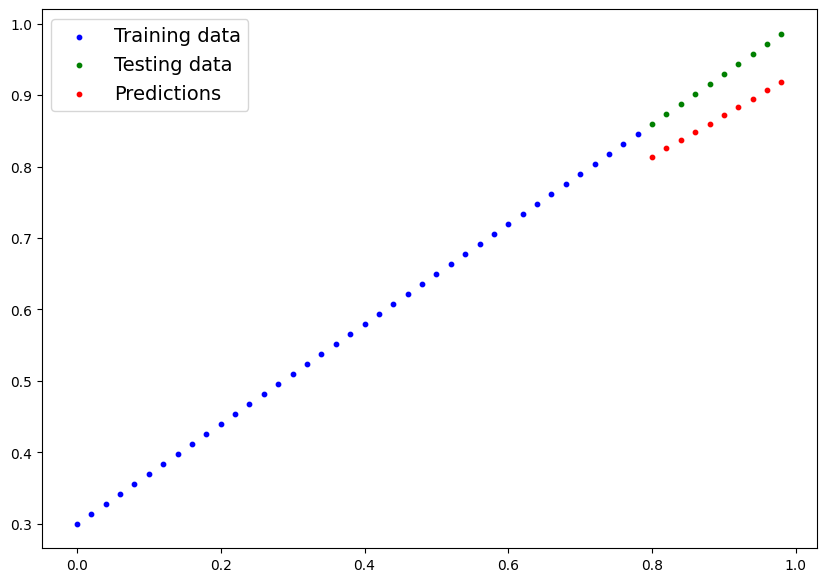

In [17]:
plot_predictions(predictions=y_preds)

The red dots are much closer now - our model learned how to get closer and start creating the line we made at the beginning!

Now, let's save and load our trained model for easy access.

### **5. Saving and loading a model (in PyTorch)**

After training a model, maybe we want to use the same model in another place. Or just have the model just in case we come back to it later. 

To do this, there are three main methods:

| PyTorch method | What does it do? |
|----------|----------|
| `torch.save()` | Saves the model to your storage using Python's `pickle` library |
| `torch.load()` | Loads the model back into memory using Python's `pickle` library |
| `torch.nn.Module.load_state_dict()` | Loads a model's parameter dictionary (`model_0.state_dict()`) using a saved `state_dict()` object. |

> Note: The pickle library is not secure, so only use `torch.load` on data/files that you trust, including when loading in saved PyTorch models

#### Saving a PyTorch model's `state_dict()`

This is the recommended way to save a model and load it later. To do this, we'll:
1. Create a folder for saving models named `models` using Python's `pathlib` library
2. Create a file path to save the model under (usually with extension `.pt` or `.pth`, as it is common convention)
3. Save the model using `torch.save(obj, f)`, where `obj` is the model's `state_dict()` and `f` is the file path

In [18]:
from pathlib import Path

# Create folder (also named a "directory") named "models"
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Create path to save model_0
MODEL_NAME = "basic_pytorch_model.pth"
MODEL_SAVE_PATH = MODEL_DIR / MODEL_NAME

# Save model_0's state dict
torch.save(obj=model_0.state_dict(),    # saving the state_dict() only saves the model's learned weights and biases
           f=MODEL_SAVE_PATH)

#### Loading a saved PyTorch model's `state_dict()`

Now that we've got a saved model `state_dict()` at `models/basic_pytorch_model.pth`, we can load it back in for further usage by calling `torch.nn.Module.load_state_dict(torch.load(f))`, where `f` is the file path for our saved model `state_dict()`.

`torch.load(f)` needs to be called within `torch.nn.Module.load_state_dict()` because we only saved the model's `state_dict()`. This isn't the entire model, and is just a dictionary of the parameters learned by the model earlier. That's why we need to load in the `state_dict()` first with `torch.load()` and then pass the same `state_dict()` to a new version of our model.
> Note: Saving the entire model makes more sense, but isn't preferred since it can cause odd errors. Therefore, we stick to just saving and loading the model's `state_dict()`

Let's try loading in the model by creating another version of `LinearRegressionModel()`, and then using `load_state_dict()` (as the model is a subclass of `torch.nn.Module` and will have `load_state_dict()` built-in)

In [19]:
# Create a new version of our model (this will be made with random weights again,
# and not the parameters learned beforehand)
loaded_model_0 = LinearRegressionModel()

# Load the state_dict of our save model (this will update the random weights with the trained weights from earlier)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

Looks like everything loaded correctly! Now, to test the loaded mode, let's perform inference (make predictions) with it on the test data. Refer to how we conducted inference above as a refresher.

In [20]:
# Put the loaded model into evaluation mode
loaded_model_0.eval()

# Use the inference_mode context manager to make predictions
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)     # do a forward pass on the test data with the loaded model

These predictions that we made should be the same as the earlier `y_preds` values. We loaded in the same parameters (weight/bias) from the model we trained earlier, which means the forward pass computation should be the same. 

Let's double check that.

In [21]:
# Compare previous model predictions with the loaded model predictions (these should be the same)
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

Hooray! It looks like our loaded model has the same predictions as the previously trained model that we saved.

Now, you've created and trained your first neural network in PyTorch! Alongside that, you can now save it and reuse it wherever you'd like it by loading the saved model back in. Congrats!